# 02 — M3/M4: V-JEPA ve V-JEPA2

Bu notebook görüntü patch'lerinden uzay-zamansal tubelet'lere geçer. Önce küçük ve okunabilir V-JEPA ile tensor akışını doğrular, sonra resmî V-JEPA/V-JEPA2 feature extraction hücrelerine geçer.

Ana soru: bir video representation modeli zamansal sıraya duyarlı olabilir; fakat bu onu neden otomatik olarak action-conditioned, causal rollout world model yapmaz?

In [19]:
from pathlib import Path
import os, sys
override = os.environ.get('JEPA_LAB_ROOT')
candidates = ([Path(override)] if override else []) + [Path.cwd(), *Path.cwd().parents, Path('/kaggle/working/jepa-study'), Path('/kaggle/working/I-JEPA'), Path('/content/jepa-study'), Path('/content/I-JEPA')]
ROOT = next((p.resolve() for p in candidates if (p / 'pyproject.toml').is_file()), None)
if ROOT is None:
    raise RuntimeError('Repo bulunamadı; JEPA_LAB_ROOT değişkenini ayarlayın.')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
print('repo:', ROOT)

repo: /kaggle/working/jepa-study


In [20]:
%matplotlib inline
from pprint import pprint
import subprocess
import torch
from torch.utils.data import DataLoader
from jepa_lab.device import seed_everything, select_device
from jepa_lab.foundations import video_token_grid, video_token_count
from jepa_lab.runlog import load_yaml

seed_everything(42)
device = select_device('auto')
config = load_yaml(ROOT / 'configs/vjepa_tiny.yaml')
print('device:', device)
pprint(config)

device: cuda
{'ablation': {'compare': ['non_causal_multiblock', 'causal_future']},
 'data': {'dataset': 'moving-shapes',
          'frames': 8,
          'image_size': 112,
          'samples': 4096},
 'experiment': 'vjepa_tiny_moving_shapes',
 'mask': {'aspect_ratio': [0.75, 1.5],
          'long_blocks': 2,
          'long_spatial_scale': [0.65, 0.75],
          'short_blocks': 8,
          'short_spatial_scale': [0.12, 0.18],
          'temporal_scale': 1.0},
 'model': {'embed_dim': 192,
           'encoder_depth': 6,
           'encoder_heads': 3,
           'patch_size': 16,
           'predictor_depth': 4,
           'predictor_dim': 192,
           'predictor_heads': 3,
           'tubelet_size': 2},
 'objective': {'ema_end': 1.0,
               'ema_start': 0.998,
               'loss': 'l1',
               'normalize_target': True},
 'optimization': {'learning_rate': 0.0005,
                  'optimizer': 'adamw',
                  'steps': 5000,
                  'weight_deca

## Tahmin 1 — Tubelet token hesabı

`[B,T,C,H,W]=[1,16,3,224,224]` ve tubelet `2×16×16`. Conv3D çıktı grid'ini ve toplam token sayısını çalıştırmadan hesaplayın. Temporal tubelet'in iki komşu frame'i tek token'a toplamasının olası avantaj/dezavantajı nedir?

In [21]:
grid = video_token_grid(frames=16, image_size=224, tubelet_size=2, patch_size=16)
tokens = video_token_count(frames=16, image_size=224, tubelet_size=2, patch_size=16)
print('grid:', grid, 'tokens:', tokens)
assert grid == (8, 14, 14) and tokens == 1568

grid: (8, 14, 14) tokens: 1568


## Sentetik hareket ve full-time tube mask

### Tahmin 2

V-JEPA'nın short/long spatial blokları neden temporal eksenin tamamına uzatılır? Sekiz küçük + iki büyük maskenin birleşiminin yaklaşık `%90` masking vermesini bekliyoruz. Her temporal slice aynı mı görünmeli?

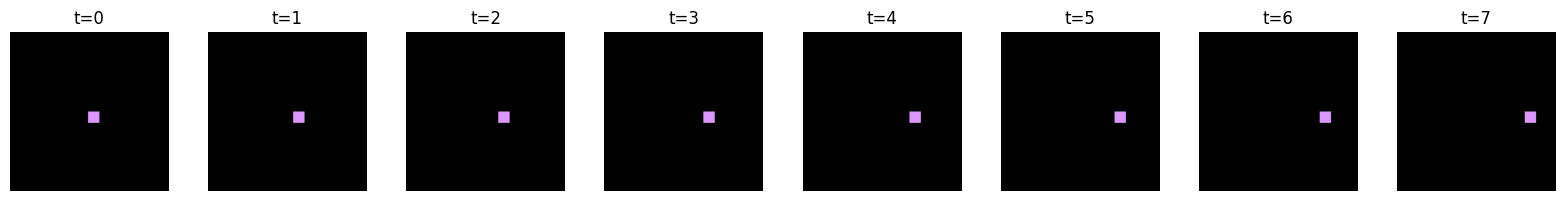

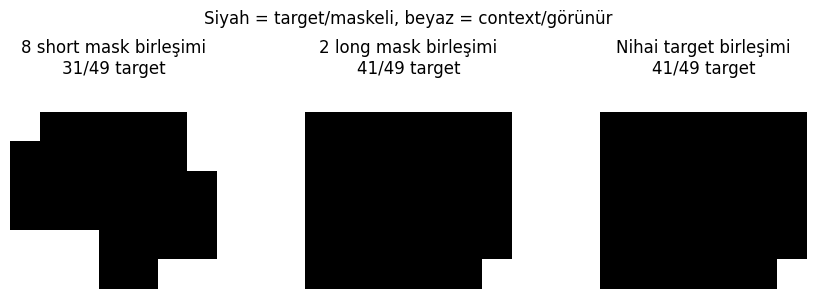

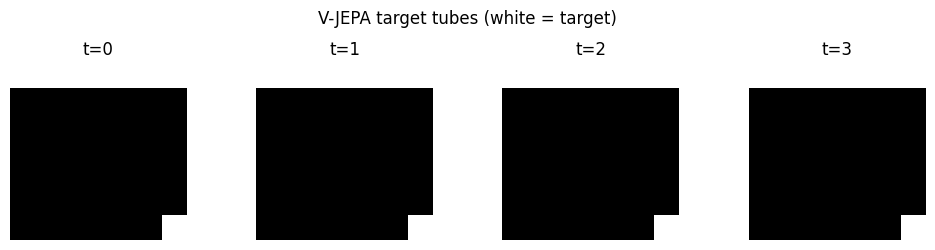

{'target_per_temporal_slice': 41, 'context_per_temporal_slice': 8, 'coverage': 0.8367347121238708}


In [22]:
import importlib
import matplotlib.pyplot as plt
from jepa_lab.datasets import MovingShapesDataset
from jepa_lab.video_jepa import TinyVideoJEPA, generate_future_mask, generate_tube_masks
import jepa_lab.visualization as visualization

# Notebook açıkken visualization.py değişmiş olabilir; eski import cache'ini yenile.
visualization = importlib.reload(visualization)
plot_tube_mask = visualization.plot_tube_mask

sample = MovingShapesDataset(samples=8, frames=8, image_size=112, seed=42)[0]
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for t, axis in enumerate(axes):
    axis.imshow(sample['frames'][t].permute(1, 2, 0))
    axis.set_title(f't={t}')
    axis.axis('off')
plt.tight_layout()
plt.show()

mask = generate_tube_masks((4, 7, 7), seed=42)
short_union = torch.stack(mask.short).any(dim=0)
long_union = torch.stack(mask.long).any(dim=0)

# Önce sekiz küçük, iki büyük ve nihai birleşimin tek temporal dilimini göster.
component_figure, component_axes = plt.subplots(1, 3, figsize=(9, 3))
component_maps = [
    ('8 short mask birleşimi', short_union[0]),
    ('2 long mask birleşimi', long_union[0]),
    ('Nihai target birleşimi', mask.target[0]),
]
for axis, (title, spatial_mask) in zip(component_axes, component_maps):
    axis.imshow(spatial_mask.cpu(), vmin=0, vmax=1, cmap='gray_r')
    axis.set_title(f'{title}\n{int(spatial_mask.sum())}/49 target')
    axis.axis('off')
component_figure.suptitle('Siyah = target/maskeli, beyaz = context/görünür')
component_figure.tight_layout()
plt.show()

# Sonra aynı spatial maskenin dört tubelet-zaman dilimine kopyalandığını göster.
tube_figure = plot_tube_mask(mask.target)
display(tube_figure)
plt.close(tube_figure)  # Jupyter'ın aynı figürü hücre sonunda tekrar çizmesini önler.

target_per_slice = int(mask.target[0].sum())
spatial_tokens = mask.target.shape[1] * mask.target.shape[2]
print({
    'target_per_temporal_slice': target_per_slice,
    'context_per_temporal_slice': spatial_tokens - target_per_slice,
    'coverage': mask.coverage,
})
assert all(torch.equal(mask.target[0], mask.target[t]) for t in range(1, 4))

### İncele 2

Full-time tube, aynı spatial bölgeyi zaman boyunca gizler; predictor yalnız komşu frame'deki aynı piksel konumunu kopyalayamaz. Küçük grid'de on mask tüm alanı kapatabileceği için laboratuvar implementasyonu en az `%10` context kalacak şekilde union'ı deterministik sınırlar.

## V-JEPA forward: `[B,T,C,H,W] → [B,N,D]`

### Tahmin 3

Teacher tam videoyu mu, yalnız target tubelet'leri mi encoder'a verir? Target seçiminin encoder'dan önce yapılması hangi bağlamsal bilgiyi yok ederdi?

In [23]:
video_model = TinyVideoJEPA(
    num_frames=8, image_size=112, tubelet_size=(2, 16, 16),
    embed_dim=48, encoder_depth=1, encoder_heads=3,
    predictor_dim=48, predictor_depth=1, predictor_heads=3,
).to(device)
frames = sample['frames'].unsqueeze(0).to(device)
with torch.no_grad():
    full_teacher = video_model.encode(frames)
output = video_model(frames, mask.target.to(device))
print('input canonical:', tuple(frames.shape))
print('latent grid:', video_model.grid_size)
print('full teacher:', tuple(full_teacher.shape))
print('prediction:', tuple(output.prediction.shape), 'target:', tuple(output.target.shape))
print('L1:', float(output.loss.detach()))
assert full_teacher.shape == (1, 196, 48)
assert output.prediction.shape == output.target.shape

input canonical: (1, 8, 3, 112, 112)
latent grid: (4, 7, 7)
full teacher: (1, 196, 48)
prediction: (1, 164, 48) target: (1, 164, 48)
L1: 0.9032385349273682


In [24]:
video_opt = torch.optim.AdamW([*video_model.context_encoder.parameters(), *video_model.predictor.parameters()], lr=1e-3)
video_opt.zero_grad(set_to_none=True)
output = video_model(frames, mask.target.to(device))
output.loss.backward()
target_has_grad = any(p.grad is not None for p in video_model.target_encoder.parameters())
student_grad = sum(float(p.grad.square().sum()) for p in video_model.context_encoder.parameters() if p.grad is not None) ** 0.5
print({'target_has_grad': target_has_grad, 'student_grad_norm': student_grad})
assert not target_has_grad and student_grad > 0

{'target_has_grad': False, 'student_grad_norm': 1.1981827609484876}


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:897.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## Hızlı sentetik V-JEPA eğitimi

`configs/vjepa_tiny.yaml` uzun koşu için `8×112×112`, width `192`, 5000 adım tanımlar. Bu hücre tensor mekanizmasını hızlı doğrulamak için `8×64×64`, width `48`, 20 adım kullanır. Sonuç bir benchmark değildir.

In [25]:
from jepa_lab.experiments import train_video_steps

quick_dataset = MovingShapesDataset(samples=128, frames=8, image_size=64, seed=42)
quick_loader = DataLoader(quick_dataset, batch_size=4, shuffle=False, num_workers=0)
trained_video = TinyVideoJEPA(
    num_frames=8, image_size=64, tubelet_size=(2, 16, 16),
    embed_dim=48, encoder_depth=1, encoder_heads=3,
    predictor_dim=48, predictor_depth=1, predictor_heads=3,
)
quick_opt = torch.optim.AdamW([*trained_video.context_encoder.parameters(), *trained_video.predictor.parameters()], lr=1e-3)
video_metrics = train_video_steps(trained_video, quick_loader, quick_opt, steps=20, device=device, seed=42)
pprint(video_metrics.as_dict())

# Aynı target latent'lerini batch içinde kaydırmak, doğru clip-target eşleşmesini bozar.
comparison_batch = next(iter(quick_loader))['frames'].to(device)
comparison_mask = generate_tube_masks(trained_video.grid_size, seed=404).target.to(device)
with torch.inference_mode():
    comparison = trained_video(comparison_batch, comparison_mask)
    matched_l1 = torch.nn.functional.l1_loss(comparison.prediction, comparison.target)
    shuffled_l1 = torch.nn.functional.l1_loss(
        comparison.prediction, torch.roll(comparison.target, shifts=1, dims=0)
    )
print({
    'matched_target_L1': float(matched_l1), 'shuffled_target_L1': float(shuffled_l1),
    'matched_is_lower': bool(matched_l1 < shuffled_l1),
})

RUN_5000_STEP_VJEPA = True
full_video = None
if RUN_5000_STEP_VJEPA:
    from jepa_lab.checkpointing import save_training_checkpoint
    from jepa_lab.runlog import build_run_summary, write_run_summary
    video_data = MovingShapesDataset(samples=4096, frames=8, image_size=112, seed=42)
    video_loader = DataLoader(video_data, batch_size=8, shuffle=True, num_workers=2)
    vm = config['model']
    full_video = TinyVideoJEPA(
        num_frames=8, image_size=112, tubelet_size=(2, 16, 16),
        embed_dim=vm['embed_dim'], encoder_depth=vm['encoder_depth'],
        encoder_heads=vm['encoder_heads'], predictor_dim=vm['predictor_dim'],
        predictor_depth=vm['predictor_depth'], predictor_heads=vm['predictor_heads'],
    )
    full_opt = torch.optim.AdamW(
        [*full_video.context_encoder.parameters(), *full_video.predictor.parameters()],
        lr=config['optimization']['learning_rate'],
        weight_decay=config['optimization']['weight_decay'],
    )
    full_metrics = train_video_steps(
        full_video, video_loader, full_opt, steps=5000, device=device, seed=42,
        ema_start=0.998, ema_end=1.0,
    )
    checkpoint = save_training_checkpoint(
        ROOT / 'runs/vjepa_tiny_5000.pt', full_video, full_opt, step=5000,
        metadata={'seed': 42, 'dataset': 'moving-shapes', 'scope': 'teaching-scale'},
    )
    summary = build_run_summary(config, full_metrics.as_dict(), {'checkpoint': str(checkpoint)})
    print('summary:', write_run_summary(summary, ROOT / 'runs'))
    pprint(full_metrics.as_dict())
else:
    print('5000-step koşu atlandı; Kaggle GPU hazır olduğunda bayrağı açın.')

# Acceptance kıyası varsa 5.000-step encoder'ı, yoksa yalnız quick modeli kullanır.
acceptance_video = full_video if full_video is not None else trained_video
acceptance_size = 112 if full_video is not None else 64
acceptance_loader = DataLoader(
    MovingShapesDataset(samples=32, frames=8, image_size=acceptance_size, seed=404),
    batch_size=16, shuffle=False, num_workers=0,
)
acceptance_frames = next(iter(acceptance_loader))['frames'].to(device)
acceptance_mask = generate_tube_masks(acceptance_video.grid_size, seed=404).target.to(device)
with torch.inference_mode():
    acceptance_output = acceptance_video(acceptance_frames, acceptance_mask)
    acceptance_matched = torch.nn.functional.l1_loss(
        acceptance_output.prediction, acceptance_output.target
    )
    acceptance_shuffled = torch.nn.functional.l1_loss(
        acceptance_output.prediction, torch.roll(acceptance_output.target, shifts=1, dims=0)
    )
print({
    'model_budget': 5000 if full_video is not None else 20,
    'matched_target_L1': float(acceptance_matched),
    'shuffled_target_L1': float(acceptance_shuffled),
    'passes_matched_lower': bool(acceptance_matched < acceptance_shuffled),
})

{'effective_rank': 18.70639419555664,
 'feature_std': 0.1730237901210785,
 'final_loss': 0.25208547711372375,
 'first_loss': 0.9739450812339783,
 'mean_cosine': 0.9692065119743347,
 'mean_loss': 0.4404429316520691,
 'steps': 20.0}
{'matched_target_L1': 0.2538060247898102, 'shuffled_target_L1': 0.2538060247898102, 'matched_is_lower': False}


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:897.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


summary: /kaggle/working/jepa-study/runs/vjepa_tiny_moving_shapes-2026-09-17T19-10-55.007218+00-00.json
{'effective_rank': 1.7207083702087402,
 'feature_std': 0.28023844957351685,
 'final_loss': 0.1572265326976776,
 'first_loss': 0.8815839886665344,
 'mean_cosine': 0.8884215354919434,
 'mean_loss': 0.1407940974747762,
 'steps': 5000.0}
{'model_budget': 5000, 'matched_target_L1': 0.15472964942455292, 'shuffled_target_L1': 0.1547296643257141, 'passes_matched_lower': True}


## Temporal perturbation

### Tahmin 4

Aynı klibin normal, ters, shuffled ve tek-frame-tekrar sürümlerinin mean-pooled feature cosine'ları nasıl sıralanır? Random-init veya 20-step modelde bu sıralamanın anlamsal kanıt sayılamayacağını da açıklayın.

In [26]:
from jepa_lab.adapters import temporal_variants, cosine_to_reference

probe_frames = MovingShapesDataset(samples=1, frames=8, image_size=64, seed=7)[0]['frames'].unsqueeze(0).to(device)
variants = temporal_variants(probe_frames)
with torch.inference_mode():
    variant_features = {name: trained_video.encode(value).cpu() for name, value in variants.items()}
temporal_cosines = cosine_to_reference(variant_features)
pprint(temporal_cosines)

{'normal': 1.0,
 'reversed': 0.9974431991577148,
 'shuffled': 0.9986887574195862,
 'static': 0.9926066398620605}


## Non-causal multiblock ↔ causal future ablation

Aşağıdaki causal maske yalnız grid'in ikinci temporal yarısını target yapar. Tek forward loss kıyaslaması eğitim sonucu değildir; gerçek ablation için iki modeli aynı seed/step bütçesiyle ayrı eğitin. Non-causal V-JEPA representation öğrenirken geçmiş ve gelecek bağlamı kullanabilir; robot planning rollout'u ise gelecek gözlemi göremez.

In [32]:
causal_future = generate_future_mask(trained_video.grid_size)
noncausal = generate_tube_masks(trained_video.grid_size, seed=123).target
with torch.inference_mode():
    causal_loss = float(trained_video(probe_frames, causal_future.to(device)).loss)
    noncausal_loss = float(trained_video(probe_frames, noncausal.to(device)).loss)
print({'same_model_causal_future_L1': causal_loss, 'same_model_noncausal_L1': noncausal_loss})

RUN_CAUSAL_ABLATION = True
CAUSAL_ABLATION_STEPS = 100
if RUN_CAUSAL_ABLATION:
    def fit_mask_ablation(mask_factory):
        seed_everything(42)
        candidate = TinyVideoJEPA(
            num_frames=8, image_size=64, tubelet_size=(2, 16, 16),
            embed_dim=48, encoder_depth=1, encoder_heads=3,
            predictor_dim=48, predictor_depth=1, predictor_heads=3,
        )
        candidate_opt = torch.optim.AdamW(
            [*candidate.context_encoder.parameters(), *candidate.predictor.parameters()], lr=1e-3
        )
        return train_video_steps(
            candidate, quick_loader, candidate_opt, steps=CAUSAL_ABLATION_STEPS,
            device=device, seed=42, mask_factory=mask_factory,
        ).as_dict()
    noncausal_metrics = fit_mask_ablation(None)
    causal_metrics = fit_mask_ablation(lambda grid, _seed: generate_future_mask(grid))
    pprint({'noncausal_multiblock': noncausal_metrics, 'causal_future': causal_metrics})
else:
    print('Eşit bütçeli kısa eğitim için RUN_CAUSAL_ABLATION=True yapın.')

{'same_model_causal_future_L1': 0.26131829619407654, 'same_model_noncausal_L1': 0.2564506530761719}
{'causal_future': {'effective_rank': 19.53341293334961,
                   'feature_std': 0.17123638093471527,
                   'final_loss': 0.12132944911718369,
                   'first_loss': 0.9782292246818542,
                   'mean_cosine': 0.9699262380599976,
                   'mean_loss': 0.19337577253580093,
                   'steps': 100.0},
 'noncausal_multiblock': {'effective_rank': 19.43019676208496,
                          'feature_std': 0.1708773821592331,
                          'final_loss': 0.1289641559123993,
                          'first_loss': 1.0092333555221558,
                          'mean_cosine': 0.9699612855911255,
                          'mean_loss': 0.19476333767175674,
                          'steps': 100.0}}


## Motion-direction probe — isteğe bağlı kısa değerlendirme

Encoder dondurulur; yalnız linear head eğitilir. Kabul ölçütü, aynı mimarideki random-init encoder'ın probe skorunu en az 10 yüzde puan aşmaktır. Dört sınıflı görevin `%25` şans düzeyi ayrıca raporlanabilir ama random-encoder kontrolünün yerini tutmaz. 20-step encoder bunu geçmeyebilir; o durumda 5000-step Kaggle koşusunun feature'larıyla tekrar deneyin.

In [36]:
RUN_DIRECTION_PROBE = True
if RUN_DIRECTION_PROBE:
    from jepa_lab.evaluation import evaluate_representation
    probe_encoder = full_video if full_video is not None else trained_video
    probe_size = 112 if full_video is not None else 64
    @torch.inference_mode()
    def freeze_features(encoder, dataset):
        loader = DataLoader(dataset, batch_size=16, shuffle=False)
        xs, ys = [], []
        for batch in loader:
            xs.append(encoder.encode(batch['frames'].to(device)).mean(1).cpu())
            ys.append(batch['label'])
        return torch.cat(xs), torch.cat(ys)
    train_data = MovingShapesDataset(samples=256, frames=8, image_size=probe_size, seed=1000)
    val_data = MovingShapesDataset(samples=128, frames=8, image_size=probe_size, seed=9000)
    x_train, y_train = freeze_features(probe_encoder, train_data)
    x_val, y_val = freeze_features(probe_encoder, val_data)
    trained_scores = evaluate_representation(x_train, y_train, x_val, y_val, k=20, probe_steps=200)
    seed_everything(42)
    if full_video is None:
        random_video = TinyVideoJEPA(
            num_frames=8, image_size=64, tubelet_size=(2, 16, 16),
            embed_dim=48, encoder_depth=1, encoder_heads=3,
            predictor_dim=48, predictor_depth=1, predictor_heads=3,
        ).to(device)
    else:
        random_video = TinyVideoJEPA(
            num_frames=8, image_size=112, tubelet_size=(2, 16, 16),
            embed_dim=vm['embed_dim'], encoder_depth=vm['encoder_depth'],
            encoder_heads=vm['encoder_heads'], predictor_dim=vm['predictor_dim'],
            predictor_depth=vm['predictor_depth'], predictor_heads=vm['predictor_heads'],
        ).to(device)
    random_train_x, random_train_y = freeze_features(random_video, train_data)
    random_val_x, random_val_y = freeze_features(random_video, val_data)
    random_scores = evaluate_representation(
        random_train_x, random_train_y, random_val_x, random_val_y, k=20, probe_steps=200
    )
    probe_deltas = {
        'knn': trained_scores.knn_accuracy - random_scores.knn_accuracy,
        'linear': trained_scores.linear_accuracy - random_scores.linear_accuracy,
    }
    pprint({
        'trained': trained_scores.as_dict(), 'random_encoder': random_scores.as_dict(),
        'trained_minus_random': probe_deltas,
        'passes_knn_plus_10': probe_deltas['knn'] >= 0.10,
        'passes_linear_plus_10': probe_deltas['linear'] >= 0.10,
    })
else:
    print('Atlandı. Probe için RUN_DIRECTION_PROBE=True yapın.')

{'passes_knn_plus_10': False,
 'passes_linear_plus_10': False,
 'random_encoder': {'knn_accuracy': 1.0,
                    'linear_accuracy': 1.0,
                    'majority_baseline': 0.328125},
 'trained': {'knn_accuracy': 0.9609375,
             'linear_accuracy': 0.765625,
             'majority_baseline': 0.328125},
 'trained_minus_random': {'knn': -0.0390625, 'linear': -0.234375}}


## Resmî V-JEPA v1 — ayrı process

İlk hücre checkpoint indirmeden pinned Meta kodunun shape smoke test'ini yapar. Pretrained ViT-L deneyi için `configs/checkpoints.yaml` adresindeki dosyayı `checkpoints/` altına indirin; sonra `vit_large`, 16 frame, 224 çözünürlükle çalıştırın. Büyük model hücreleri Kaggle GPU içindir.

In [37]:
RUN_OFFICIAL_VJEPA_SHAPE = True
if RUN_OFFICIAL_VJEPA_SHAPE:
    subprocess.run([
        sys.executable, str(ROOT / 'scripts/official_vjepa_features.py'),
        '--device', str(device), '--model', 'vit_tiny', '--frames', '8', '--image-size', '112',
    ], cwd=ROOT, check=True)
else:
    print('Atlandı. RUN_OFFICIAL_VJEPA_SHAPE=True yapın.')

/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


{
  "implementation": "facebookresearch/jepa@51c59d51",
  "weights": "random-init shape smoke only",
  "device": "cuda",
  "canonical_input_shape": [
    1,
    8,
    3,
    112,
    112
  ],
  "upstream_input_shape": [
    1,
    3,
    8,
    112,
    112
  ],
  "token_grid": [
    4,
    7,
    7
  ],
  "expected_tokens": 196,
  "feature_shape": [
    1,
    196,
    192
  ],
  "cosine_to_normal": {
    "normal": 1.0,
    "reversed": 0.9999955892562866,
    "shuffled": 1.0000001192092896,
    "static": 0.9999579191207886
  },
  "load_result": {
    "checkpoint": null,
    "missing": [],
    "unexpected": []
  },
  "variant_order": [
    "normal",
    "reversed",
    "shuffled",
    "static"
  ],
  "stimulus_id": "moving-square-left-to-right-v1",
  "pooling": "raw patch tokens exported; mean pooling used for cosine",
  "preprocessing": "deterministic RGB synthetic clip, ImageNet mean/std"
}


In [40]:
RUN_PRETRAINED_VJEPA_VITL = True
checkpoint_candidates = [ROOT / 'checkpoints/vitl16.pth.tar']
if Path('/kaggle/input').is_dir():
    checkpoint_candidates.extend(Path('/kaggle/input').rglob('vitl16.pth.tar'))
    checkpoint_candidates.extend(Path('/kaggle/input').rglob('vitl16.pth'))
vjepa_checkpoint = next((path for path in checkpoint_candidates if path.is_file()), None)
pretrained_vjepa_path = ROOT / 'runs/vjepa_v1_temporal_features.npz'
if RUN_PRETRAINED_VJEPA_VITL:
    if vjepa_checkpoint is None:
        raise FileNotFoundError(
            "vitl16.pth.tar bulunamadı; checkpoint'i Kaggle Input olarak ekleyin."
        )
    print('Checkpoint:', vjepa_checkpoint)
    subprocess.run([
        sys.executable, str(ROOT / 'scripts/official_vjepa_features.py'),
        '--device', str(device), '--model', 'vit_large', '--frames', '16', '--image-size', '224',
        '--checkpoint', str(vjepa_checkpoint),
        '--output', str(pretrained_vjepa_path),
    ], cwd=ROOT, check=True)
else:
    print('Atlandı. Kaggle GPU + checkpoint hazır olduğunda bayrağı açın.')

Checkpoint: /kaggle/input/datasets/ercankurtoglu/vjepa-vitl16-224/vitl16.pth.tar


/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


{
  "implementation": "facebookresearch/jepa@51c59d51",
  "weights": "pretrained",
  "device": "cuda",
  "canonical_input_shape": [
    1,
    16,
    3,
    224,
    224
  ],
  "upstream_input_shape": [
    1,
    3,
    16,
    224,
    224
  ],
  "token_grid": [
    8,
    14,
    14
  ],
  "expected_tokens": 1568,
  "feature_shape": [
    1,
    1568,
    1024
  ],
  "cosine_to_normal": {
    "normal": 1.0000001192092896,
    "reversed": 0.9442704319953918,
    "shuffled": 0.9322245121002197,
    "static": 0.7932534217834473
  },
  "load_result": {
    "checkpoint": "/kaggle/input/datasets/ercankurtoglu/vjepa-vitl16-224/vitl16.pth.tar",
    "sha256": "0cd3bfce97d04891a31eac70d573ef94f423d858a6b0dc0b3ddf5f8d00b33fe4",
    "missing": [],
    "unexpected": []
  },
  "variant_order": [
    "normal",
    "reversed",
    "shuffled",
    "static"
  ],
  "stimulus_id": "moving-square-left-to-right-v1",
  "pooling": "raw patch tokens exported; mean pooling used for cosine",
  "preprocessing

### Resmî V-JEPA v1 feature görselleştirmesi

Dört temporal varyantın seçili frame'lerini, global cosine matrisini ve token değişimini birlikte inceleyin. Token değişimi attention değildir; aynı `(t, y, x)` konumundaki encoder feature'ının normale göre ne kadar değiştiğini gösterir. Reversed ve shuffled videolarda aynı temporal indeks farklı kaynak frame'e karşılık geldiği için harita hem sıra değişimini hem bağlamsal yayılımı içerir.

In [ ]:
import importlib
import json
import numpy as np
import matplotlib.pyplot as plt
from jepa_lab.adapters import temporal_variants
import jepa_lab.stimuli as stimuli
stimuli = importlib.reload(stimuli)
moving_square_video = stimuli.moving_square_video
video_clip_from_file = stimuli.video_clip_from_file

def plot_temporal_views(clip, title):
    views = temporal_variants(clip.cpu())
    selected = np.rint(np.linspace(0, clip.shape[1] - 1, 4)).astype(int)
    figure, axes = plt.subplots(4, 4, figsize=(12, 10))
    for row, (name, frames_value) in enumerate(views.items()):
        for column, frame_index in enumerate(selected):
            axes[row, column].imshow(frames_value[0, frame_index].permute(1, 2, 0))
            axes[row, column].set_title(f'{name}: t={frame_index}')
            axes[row, column].axis('off')
    figure.suptitle(title)
    figure.tight_layout()
    plt.show()

def analyse_temporal_archive(path, title):
    path = Path(path)
    with np.load(path, allow_pickle=False) as archive:
        features = archive['features']
    sidecar = json.loads(path.with_suffix(path.suffix + '.json').read_text())
    metadata = sidecar['metadata']
    names = list(metadata['variant_order'])
    temporal, height, width = metadata['token_grid']
    assert features.shape[1] == temporal * height * width

    pooled = features.mean(axis=1)
    pooled /= np.linalg.norm(pooled, axis=1, keepdims=True) + 1e-8
    similarity = pooled @ pooled.T
    figure, axes = plt.subplots(1, 2, figsize=(13, 5))
    matrix = axes[0].imshow(similarity, cmap='viridis', vmin=-1.0, vmax=1.0)
    axes[0].set_xticks(range(len(names)), names, rotation=35, ha='right')
    axes[0].set_yticks(range(len(names)), names)
    axes[0].set_title('Mean-pooled feature cosine matrisi')
    for row in range(len(names)):
        for column in range(len(names)):
            axes[0].text(column, row, f'{similarity[row, column]:.3f}',
                         ha='center', va='center', color='white')
    figure.colorbar(matrix, ax=axes[0], label='cosine similarity')
    reference_values = similarity[0, 1:]
    axes[1].bar(names[1:], reference_values)
    axes[1].set_ylim(-1.0, 1.0)
    axes[1].set_ylabel('normal ile cosine similarity')
    axes[1].set_title('Normal videoya global benzerlik')
    axes[1].tick_params(axis='x', rotation=35)
    for index, value in enumerate(reference_values):
        axes[1].text(index, value, f'{value:.3f}', ha='center', va='bottom')
    figure.suptitle(title)
    figure.tight_layout()
    plt.show()

    normal = features[0] / (np.linalg.norm(features[0], axis=-1, keepdims=True) + 1e-8)
    aligned_names = [name for name in ('reversed', 'shuffled', 'static') if name in names]
    changes = {}
    for name in aligned_names:
        index = names.index(name)
        candidate = features[index] / (
            np.linalg.norm(features[index], axis=-1, keepdims=True) + 1e-8
        )
        changes[name] = (1.0 - np.sum(normal * candidate, axis=-1)).reshape(
            temporal, height, width
        )
    shared_max = max(float(np.percentile(value, 99)) for value in changes.values())
    figure, axes = plt.subplots(len(changes), 2, figsize=(11, 3 * len(changes)))
    for row, (name, change) in enumerate(changes.items()):
        heat = axes[row, 0].imshow(
            change.mean(axis=0), cmap='magma', vmin=0.0, vmax=shared_max
        )
        axes[row, 0].set_title(f'{name}: zaman ortalamalı spatial değişim')
        axes[row, 0].set_xlabel('token x')
        axes[row, 0].set_ylabel('token y')
        axes[row, 1].plot(np.arange(temporal), change.mean(axis=(1, 2)), marker='o')
        axes[row, 1].set_title(f'{name}: temporal değişim')
        axes[row, 1].set_xlabel('temporal token')
        axes[row, 1].set_ylabel('ortalama 1 − token cosine')
    figure.colorbar(heat, ax=axes[:, 0], shrink=0.75, label='1 − token cosine')
    figure.suptitle('V-JEPA token duyarlılığı — attention değildir')
    figure.tight_layout()
    plt.show()
    print('Feature shape:', features.shape)
    return {'names': names, 'similarity': similarity, 'features': features}

if pretrained_vjepa_path.is_file():
    synthetic_clip = moving_square_video(16, 224)
    plot_temporal_views(synthetic_clip, 'Sentetik klibin temporal varyantları')
    synthetic_analysis = analyse_temporal_archive(
        pretrained_vjepa_path, 'Pretrained resmî V-JEPA v1 — sentetik klip'
    )
else:
    print('Önce pretrained V-JEPA hücresini çalıştırın:', pretrained_vjepa_path)

### Gerçek video deneyi

Kendi MP4/MOV/AVI dosyanızı Kaggle Dataset olarak ekleyin ve `REAL_VIDEO_PATH` değerini ayarlayın. İsterseniz farklı içerikli ikinci videoyu `DIFFERENT_VIDEO_PATH` olarak verin; bu, normal/reversed/shuffled/static pozitif kontrollerine ek bir negatif örnek üretir. Video okuma eksikse bir kez `pip install -e '.[video]'` çalıştırın. On altı frame video boyunca eşit aralıklarla seçilir, merkezden kare kırpılır ve `224×224` yapılır.

In [ ]:
REAL_VIDEO_PATH = None       # Örnek: Path('/kaggle/input/my-videos/walk.mp4')
DIFFERENT_VIDEO_PATH = None  # İsteğe bağlı negatif video
real_video_feature_path = ROOT / 'runs/vjepa_v1_real_video_features.npz'

if REAL_VIDEO_PATH is None:
    print('Atlandı. Önce REAL_VIDEO_PATH değerini gerçek bir video dosyasına ayarlayın.')
else:
    REAL_VIDEO_PATH = Path(REAL_VIDEO_PATH)
    assert REAL_VIDEO_PATH.is_file(), REAL_VIDEO_PATH
    if DIFFERENT_VIDEO_PATH is not None:
        DIFFERENT_VIDEO_PATH = Path(DIFFERENT_VIDEO_PATH)
        assert DIFFERENT_VIDEO_PATH.is_file(), DIFFERENT_VIDEO_PATH

    real_clip, sampled_source_frames = video_clip_from_file(
        REAL_VIDEO_PATH, frames=16, image_size=224
    )
    print('Kaynak frame indeksleri:', sampled_source_frames.tolist())
    plot_temporal_views(real_clip, f'Gerçek video: {REAL_VIDEO_PATH.name}')

    command = [
        sys.executable, str(ROOT / 'scripts/official_vjepa_features.py'),
        '--device', str(device), '--model', 'vit_large',
        '--frames', '16', '--image-size', '224',
        '--checkpoint', str(vjepa_checkpoint),
        '--video', str(REAL_VIDEO_PATH),
        '--output', str(real_video_feature_path),
    ]
    if DIFFERENT_VIDEO_PATH is not None:
        command.extend(['--comparison-video', str(DIFFERENT_VIDEO_PATH)])
    subprocess.run(command, cwd=ROOT, check=True)
    real_video_analysis = analyse_temporal_archive(
        real_video_feature_path, 'Pretrained resmî V-JEPA v1 — gerçek video'
    )

## V-JEPA2: 3D RoPE ve resmî Hugging Face encoder

V-JEPA2'de V-JEPA v1'e göre izleyeceğimiz üç değişiklik: absolute 3D sin-cos yerine **3D RoPE**, daha büyük image/video karışımı ve progressive temporal/spatial resolution. Action-free encoder pretraining ile action-conditioned post-training'i birbirine karıştırmayın.

Aşağıdaki hücre `facebook/vjepa2-vitl-fpc64-256` ağırlıklarını indirir ve büyük VRAM/RAM kullanır. Önce `pip install -e '.[hf]'`; Kaggle GPU'da çalıştırın. Feature'lar `.npz` ile process sınırının dışına çıkar.

In [ ]:
RUN_OFFICIAL_VJEPA2 = False
if RUN_OFFICIAL_VJEPA2:
    subprocess.run([
        sys.executable, str(ROOT / 'scripts/official_vjepa2_features.py'),
        '--device', str(device), '--frames', '64', '--image-size', '256',
        '--output', str(ROOT / 'runs/vjepa2_temporal_features.npz'),
    ], cwd=ROOT, check=True)
else:
    print('Atlandı. Hugging Face extra + yeterli GPU hazır olduğunda bayrağı açın.')

In [ ]:
from jepa_lab.evaluation import temporal_perturbation_summary

v1_archive = ROOT / 'runs/vjepa_v1_temporal_features.npz'
v2_archive = ROOT / 'runs/vjepa2_temporal_features.npz'
if v1_archive.is_file() and v2_archive.is_file():
    pprint({'V-JEPA-v1': temporal_perturbation_summary(v1_archive).as_dict()})
    pprint({'V-JEPA2': temporal_perturbation_summary(v2_archive).as_dict()})
else:
    print('Karşılaştırma için iki resmî feature export dosyasını da üretin.')

## M3/M4 geçiş kontrolü

- `[B,T,C,H,W] → Conv3D tubelet → [B,N,D]` akışını ve 1568 token hesabını açıklayın.
- Teacher tam klibi görür; target seçimi latent çıktıdadır.
- Normal/reversed/shuffled/static sonuçlarında random-init ile pretrained kanıtı ayırın.
- V-JEPA v1 güçlü non-causal representation modelidir; action-conditioned causal dynamics değildir.
- V-JEPA2 action-free encoder pretraining ile V-JEPA2-AC post-training iki ayrı aşamadır.